# Baseline model

We import the dependencies : 

In [99]:
# !pip install cesnet-datazoo

import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn import metrics
from sklearn.metrics import confusion_matrix

from cesnet_datazoo.datasets import CESNET_QUICEXT_25
from cesnet_datazoo.config import DatasetConfig, AppSelection

## Baseline model for the supervised approach

We load the data and labelised our flows as AI (1) or non AI (0) : 

In [100]:
# Load the data
capture_ai_heavy = pd.read_csv("data/capture_ai_heavy_2.csv")
capture_ai_leger = pd.read_csv("data/capture_normal_ai_2.csv")
capture_cloud_work = pd.read_csv("data/capture_cloud_work_2.csv")
capture_normal_web= pd.read_csv("data/capture_normal_web_2.csv")
capture_streaming= pd.read_csv("data/capture_streaming_2.csv")

capture_ai_claude = pd.read_csv("data/capture_ai_claude.csv")
capture_ai_gemini_chatty = pd.read_csv("data/capture_ai_gemini_chatty.csv")
capture_metro = pd.read_csv("data/capture_metro.csv")
capture_youtube = pd.read_csv("data/capture_youtube.csv")

capture_ai_image = pd.read_csv("data/capture_ai_image.csv")
capture_ai = pd.read_csv("data/capture_ai.csv")
capture_classic_web = pd.read_csv("data/capture_classic_web.csv")
capture_streaming_3 = pd.read_csv("data/capture_streaming_3.csv")

# labelisation
normal = pd.concat([capture_cloud_work, capture_normal_web, capture_streaming, capture_metro, capture_youtube, capture_classic_web, capture_streaming_3])
ai = pd.concat([capture_ai_heavy, capture_ai_leger, capture_ai_claude, capture_ai_gemini_chatty, capture_ai_image, capture_ai])

normal["label_ia"] = 0
ai["label_ia"] = 1

supervised_dataset = pd.concat([normal, ai], ignore_index=True)
supervised_dataset.shape

(25724, 12)

We then reapply the cleaning steps from the precedent report : 

In [101]:
# delete space at the begining/end of the columns 
supervised_dataset.columns = supervised_dataset.columns.str.strip()

# Calculate of FlowBytesPerSec, FlowPacketsPerSec, AveragePacketSize
supervised_dataset["FlowBytesPerSec"] = supervised_dataset["TotBytes"] / supervised_dataset["Dur"]
supervised_dataset["FlowPacketsPerSec"] = supervised_dataset["TotPkts"] / supervised_dataset["Dur"]
supervised_dataset["AveragePacketSize"] = supervised_dataset["TotBytes"] / supervised_dataset["TotPkts"]

# Rename
supervised_dataset = supervised_dataset.rename(
    columns={
        "Dur":"FlowDuration",
        "Proto":"Protocol",
        "Dport":"DestinationPort",
        "TotPkts":"TotalPackets",
        "TotBytes":"TotalBytes",
        "State":"ConnectionState",
        "Dir":"Direction",
        "label_ia":"LabelAI"
    }
)

# Keep only the columns that we need
features = [
    "FlowDuration",
    "DestinationPort",
    "TotalPackets",
    "TotalBytes",
    "FlowBytesPerSec",
    "FlowPacketsPerSec",
    "AveragePacketSize",
    "LabelAI"
] 
supervised_dataset = supervised_dataset[features]

# Avoid division by 0
supervised_dataset = supervised_dataset[supervised_dataset["FlowDuration"] >= 0]
supervised_dataset.replace([np.inf, -np.inf], np.nan, inplace=True)
supervised_dataset.dropna(inplace=True)

# Uniformisation of the ports
supervised_dataset["DestinationPort"] = supervised_dataset["DestinationPort"].replace({
    "https":   443,
    "http":    80,
    "domain":  53,
    "dns":     53,
    "ntp":     123,
    "ssh":     22,
    "ftp":     21,
    "smtp":    25,
    "imap":    143,
    "pop3":    110,
    "ldap":    389,
    "snmp":    161,
    "quic":    443,
    "mdns":    5353,
})

We then split our data into 3 subset (train, validation and test) : 

In [102]:
supervised_train, temporary_subset = train_test_split(supervised_dataset, test_size=0.4, random_state=42)
supervised_validation, supervised_test = train_test_split(temporary_subset, test_size=0.5, random_state=42)

After that, we predict the Label AI with dummy classifiers :

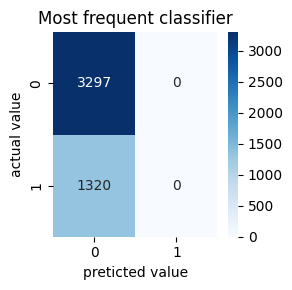

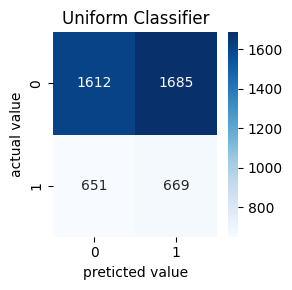

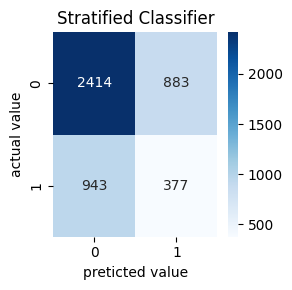

,Model,Accuracy,Cohen Kappa
0,Most frequent,0.714100,0.000000
1,Uniform,0.494044,-0.003444
2,Stratified,0.604505,0.018033


In [103]:
# Function which create the confusion matrix
def cl_plot_cm(actual_data, predicted_data, labels=None, title=None):
    if labels is None:
        labels = actual_data.cat.categories
    k = len(labels)

    # create the confusion matrix with sklearn make sure to set labels=labels
    cm = confusion_matrix(actual_data, predicted_data, labels=labels)
    
    # Get the current figure *if it exists* — without creating a new one
    fig = plt._pylab_helpers.Gcf.get_active()
    new_fig = fig is None  # True if no active figure
    # Only make a new figure if none exists
    if new_fig:  # if no active subplot
        plt.figure(figsize=(3, 3))
    # create the seaborn heatmap of the confusion matrix    
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="g")
    # set the x and y labels
    plt.xlabel('preticted value')
    plt.ylabel('actual value')
    
    # set the x and y ticks
    plt.xticks(np.arange(k)+1/k, labels)
    plt.yticks(np.arange(k)+1/k, labels)
    
    # add a title, but only if provided
    if title:
        plt.title(title)
    
    # Only show the plot if it's a standalone figure
    if new_fig:
        plt.tight_layout()
        plt.show()
    # return nothing
    return None    

y_label = 'LabelAI'
supervised_train[y_label] = pd.Categorical(supervised_train[y_label])

# Most frequent classifier 
y_train = supervised_train[y_label]
mf = DummyClassifier(strategy="most_frequent")
mf.fit(y_train, y_train)
y_hat_mf_train = mf.predict(y_train)
y_hat_mf_train[0:5]

# Uniform 
uni = DummyClassifier(strategy="uniform")
uni.fit(y_train, y_train)
y_hat_uni_train = uni.predict(y_train)

# Stratified
str = DummyClassifier(strategy="stratified")
str.fit(y_train, y_train)
y_hat_str_supervised = str.predict(y_train)

supervised_validation[y_label] = pd.Categorical(supervised_validation[y_label])

# Predictions
y_supervised = supervised_validation[y_label]
y_hat_mf_supervised = mf.predict(y_supervised)
y_hat_uni_supervised = uni.predict(y_supervised)
y_hat_str_supervised = str.predict(y_supervised)

# Confusion matrix
cl_plot_cm(y_supervised, y_hat_mf_supervised, labels=y_supervised.cat.categories, title='Most frequent classifier');
cl_plot_cm(y_supervised, y_hat_uni_supervised, labels=y_supervised.cat.categories, title='Uniform Classifier');
cl_plot_cm(y_supervised, y_hat_str_supervised, labels=y_supervised.cat.categories, title='Stratified Classifier');

# accuracy score
ac_mf_supervised = metrics.accuracy_score(y_supervised, y_hat_mf_supervised)
ac_uni_supervised = metrics.accuracy_score(y_supervised, y_hat_uni_supervised)
ac_str_supervised = metrics.accuracy_score(y_supervised, y_hat_str_supervised)

# Cohen Kappa score
k_mf_supervised = metrics.cohen_kappa_score(y_supervised, y_hat_mf_supervised)
k_uni_supervised = metrics.cohen_kappa_score(y_supervised, y_hat_uni_supervised)
k_str_supervised = metrics.cohen_kappa_score(y_supervised, y_hat_str_supervised)

acs = {
    'Model': ["Most frequent", "Uniform", "Stratified"],
    'Accuracy': [ac_mf_supervised, ac_uni_supervised, ac_str_supervised],
    'Cohen Kappa': [k_mf_supervised, k_uni_supervised, k_str_supervised]
}

pd.DataFrame(acs)